In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    auc,
    ConfusionMatrixDisplay
)

# EDA - Analyse

In [2]:
data_train = pd.read_csv('datas/conversion_data_train.csv')
data_train.head()

,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0


In [3]:
data_train.shape

(284580, 6)

In [4]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB


In [5]:
data_train.isnull().sum()/len(data_train)*100

country                0.0
age                    0.0
new_user               0.0
source                 0.0
total_pages_visited    0.0
converted              0.0
dtype: float64

In [6]:
data_converted = data_train['converted'].value_counts().reset_index()


fig = px.bar(
    data_converted,
    x='converted',
    y='count',
    labels={'converted': 'Converted (0 = No, 1 = Yes)', 'count': 'Number of users'},
    title='Distribution of Converted Users'
)
fig.show()

In [7]:
data_converted_percent = (round(data_train["converted"].value_counts(normalize=True) * 100, 2)).reset_index()

print(data_converted_percent)

conversion_rate = data_converted_percent.loc[data_converted_percent["converted"] == 1, "proportion"].values[0]
print('The actual convertion rate is', conversion_rate, "%")

   converted  proportion
0          0       96.77
1          1        3.23
The actual convertion rate is 3.23 %


In [8]:
data_age_converted = data_train.groupby("age")["converted"].sum().reset_index()
data_age_converted

fig = px.bar(
    data_age_converted,
    x="age",
    y="converted",
    labels={"age": "Âge", "converted": "Nombre de conversions"},
    title="Nombre de conversions par âge"
)
fig.show()

In [9]:
data_country_converted = data_train.groupby("country")["converted"].sum().reset_index()

fig = px.bar(
    data_country_converted,
    x="country",
    y="converted",
    labels={"country": "Country", "converted": "Nombre de conversions"},
    title="Nombre de conversions par pays"
)
fig.show()

In [10]:
data_country_converted = data_train.groupby("new_user")["converted"].sum().reset_index()

fig = px.bar(
    data_country_converted,
    x="new_user",
    y="converted",
    labels={"new_user": "New user", "converted": "Nombre de conversions"},
    title="Nombre de conversions par nouveaux utilisateurs"
)
fig.show()

In [11]:
data_country_converted = data_train.groupby("source")["converted"].sum().reset_index()

fig = px.bar(
    data_country_converted,
    x="source",
    y="converted",
    labels={"source": "Source", "converted": "Nombre de conversions"},
    title="Nombre de conversions par source"
)
fig.show()

In [12]:
data_country_converted = data_train.groupby("total_pages_visited")["converted"].sum().reset_index()

fig = px.bar(
    data_country_converted,
    x="total_pages_visited",
    y="converted",
    labels={"total_pages_visited": "Total pages visited", "converted": "Nombre de conversions"},
    title="Nombre de conversions par total pages visited"
)
fig.show()

In [13]:
import plotly.figure_factory as ff
numerical_cols = data_train.select_dtypes(include='number')
corr_matrix = numerical_cols.corr()

fig = ff.create_annotated_heatmap(
    z=corr_matrix.values.round(2),
    x=corr_matrix.columns.tolist(),
    y=corr_matrix.index.tolist(),
    colorscale='Viridis',
    showscale=True
)

fig.update_layout(title="Matrice de corrélation")
fig.show()


# Transform

In [14]:
feature_target = 'converted'
X = data_train.loc[:, data_train.columns != feature_target]
y = data_train[feature_target]

X.head()

,country,age,new_user,source,total_pages_visited
0,China,22,1,Direct,2
1,UK,21,1,Ads,3
2,Germany,20,0,Seo,14
3,US,23,1,Seo,3
4,US,28,1,Direct,3


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [16]:
numeric_features = []
categorical_features = []

for i,t in X_train.dtypes.items():
    if ('float' in str(t)) or ('int' in str(t)) :
        numeric_features.append(i)
    else :
        categorical_features.append(i)

print('Found numeric features ', numeric_features)
print('Found categorical features ', categorical_features)

Found numeric features  ['age', 'new_user', 'total_pages_visited']
Found categorical features  ['country', 'source']


In [17]:
numeric_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ])

categorical_transformer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(drop='first'))
    ])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [18]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric="logloss"),
}

results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=10)
    results.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Standard Deviation": scores.std()
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="Mean Accuracy", ascending=False)

,Model,Mean Accuracy,Standard Deviation
0,Logistic Regression,0.986211,0.000469
2,XGBoost,0.985881,0.000500
1,Random Forest,0.984827,0.000347


In [19]:
# Logistic Regression
logistic_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
logistic_pipeline.fit(X_train, y_train)

# Random Forest
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])
rf_pipeline.fit(X_train, y_train)

# XGBoost
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(eval_metric="logloss"))
])
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'new_user',
                                                   'total_pages_visited']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['country', 'source'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsam...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, ...))])

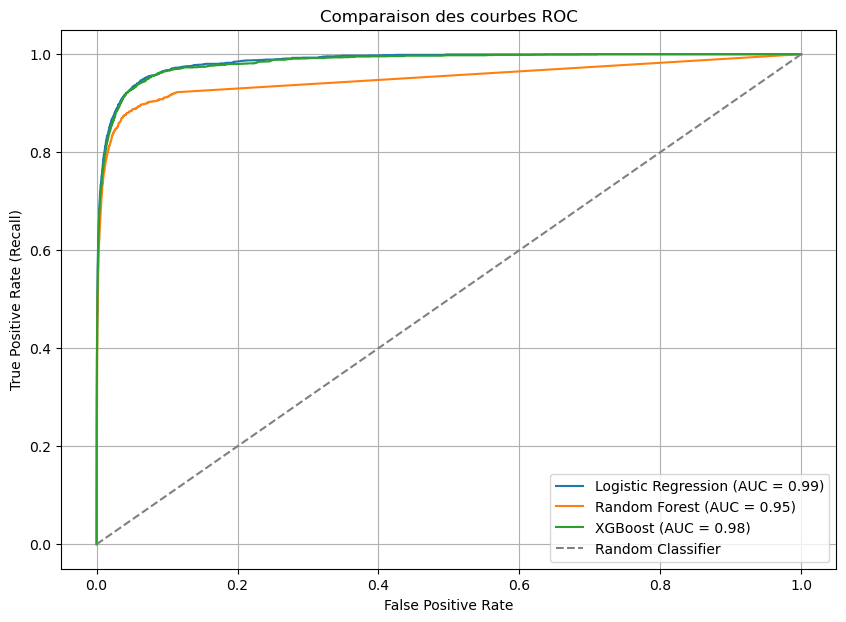

In [20]:
#from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline
}

plt.figure(figsize=(10, 7))

for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Classifier')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Comparaison des courbes ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [21]:
y_pred_logistic = logistic_pipeline.predict(X_test)
print(f"📋 Classification Report — Logistic Regression")
print(classification_report(y_test, y_pred_logistic))

📋 Classification Report — Logistic Regression
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     68850
           1       0.86      0.68      0.76      2295

    accuracy                           0.99     71145
   macro avg       0.92      0.84      0.88     71145
weighted avg       0.99      0.99      0.99     71145



In [22]:
y_pred_xgb = xgb_pipeline.predict(X_test)
print(f"📋 Classification Report — XGBoost")
print(classification_report(y_test, y_pred_xgb))

📋 Classification Report — XGBoost
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     68850
           1       0.84      0.69      0.76      2295

    accuracy                           0.99     71145
   macro avg       0.92      0.84      0.87     71145
weighted avg       0.98      0.99      0.99     71145



In [23]:
y_pred_rf = rf_pipeline.predict(X_test)
print(f"📋 Classification Report — Random Forest")
print(classification_report(y_test, y_pred_rf))

📋 Classification Report — Random Forest
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     68850
           1       0.80      0.67      0.73      2295

    accuracy                           0.98     71145
   macro avg       0.90      0.83      0.86     71145
weighted avg       0.98      0.98      0.98     71145



In [37]:
choosed_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
    'classifier__scale_pos_weight': [1, 5, 10, 30]
}

grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Best parameters :", grid_search.best_params_)
print("Best F1 score :", grid_search.best_score_)

best_xgb_model = grid_search.best_estimator_
best_xgb_model

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__scale_pos_weight=1, classifier__subsample=0.8; total time=   3.5s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__scale_pos_weight=1, classifier__subsample=0.8; total time=   3.5s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__scale_pos_weight=1, classifier__subsample=1.0; total time=   3.4s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__scale_pos_weight=1, classifier__subsample=0.8; total time=   3.5s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, classifier__n_estimators=100, classifier__scale_pos_weight=1, classifier__subsample=0.8; total time=   3.5s
[CV] END classifier__learning_rate=0.01, classifier__max_depth=3, c

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'new_user',
                                                   'total_pages_visited']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['country', 'source'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsam...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [42]:
best_params = grid_search.best_params_
print(best_params)

clean_params = {k.split('__')[-1]: v for k, v in best_params.items()}
print(clean_params)

{'classifier__learning_rate': 0.1, 'classifier__max_depth': 5, 'classifier__n_estimators': 200, 'classifier__scale_pos_weight': 1, 'classifier__subsample': 1.0}
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 1, 'subsample': 1.0}


In [43]:
final_model = XGBClassifier(**clean_params, random_state=42)

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', final_model)
])

final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'new_user',
                                                   'total_pages_visited']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['country', 'source'])])),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsam...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [44]:
y_pred = final_pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     68850
           1       0.85      0.69      0.76      2295

    accuracy                           0.99     71145
   macro avg       0.92      0.84      0.88     71145
weighted avg       0.99      0.99      0.99     71145



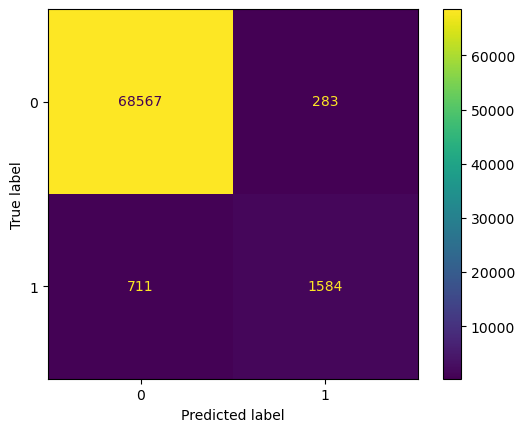

In [45]:
ConfusionMatrixDisplay.from_estimator(final_pipeline, X_test, y_test)

In [46]:
model = final_pipeline.named_steps['classifier']
importances = model.feature_importances_

feature_names = final_pipeline.named_steps['preprocessor'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df

,feature,importance
2,num__total_pages_visited,0.683637
1,num__new_user,0.126776
4,cat__country_UK,0.069485
3,cat__country_Germany,0.050368
5,cat__country_US,0.044166
0,num__age,0.014429
6,cat__source_Direct,0.007069
7,cat__source_Seo,0.004069


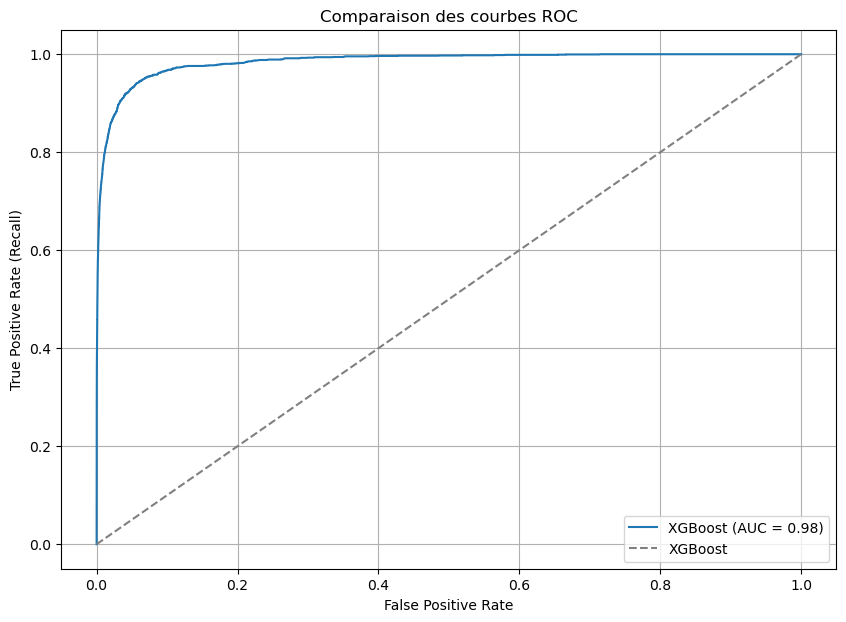

In [47]:
plt.figure(figsize=(10, 7))

y_proba = final_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='XGBoost')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Comparaison des courbes ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()